In [1]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import MinMaxScaler

pd.set_option("display.max_columns", None)

sns.set_theme(style="whitegrid")



df = pd.read_csv(
    "../data/restaurant_performance_analysis.csv"
)

print("Dataset shape:", df.shape)

display(df.head())

Dataset shape: (7403, 27)


,Restaurant ID,Restaurant Name,Country Code,City,Address,Locality,Locality Verbose,Longitude,Latitude,Cuisines,Average Cost for two,Currency,Has Table booking,Has Online delivery,Is delivering now,Switch to order menu,Price range,Aggregate rating,Rating color,Rating text,Votes,Log Votes,Rating Score,Popularity Score,Performance Score,Performance Segment,Digital Adoption
0,6317637,Le Petit Souffle,162,Makati City,"Third Floor, Century City Mall, Kalayaan Avenu...","Century City Mall, Poblacion, Makati City","Century City Mall, Poblacion, Makati City, Mak...",121.027535,14.565443,"French, Japanese, Desserts",1100.0,Botswana Pula(P),Yes,No,No,No,3,4.8,Dark Green,Excellent,314,5.752573,0.967742,0.538749,0.796145,High Performer,One Service
1,6304287,Izakaya Kikufuji,162,Makati City,"Little Tokyo, 2277 Chino Roces Avenue, Legaspi...","Little Tokyo, Legaspi Village, Makati City","Little Tokyo, Legaspi Village, Makati City, Ma...",121.014101,14.553708,Japanese,1200.0,Botswana Pula(P),Yes,No,No,No,3,4.5,Dark Green,Excellent,591,6.383507,0.870968,0.620792,0.770897,High Performer,One Service
2,6300002,Heat - Edsa Shangri-La,162,Mandaluyong City,"Edsa Shangri-La, 1 Garden Way, Ortigas, Mandal...","Edsa Shangri-La, Ortigas, Mandaluyong City","Edsa Shangri-La, Ortigas, Mandaluyong City, Ma...",121.056831,14.581404,"Seafood, Asian, Filipino, Indian",4000.0,Botswana Pula(P),Yes,No,No,No,4,4.4,Green,Very Good,270,5.602119,0.838710,0.519185,0.710900,High Performer,One Service
3,6318506,Ooma,162,Mandaluyong City,"Third Floor, Mega Fashion Hall, SM Megamall, O...","SM Megamall, Ortigas, Mandaluyong City","SM Megamall, Ortigas, Mandaluyong City, Mandal...",121.056475,14.585318,"Japanese, Sushi",1500.0,Botswana Pula(P),No,No,No,No,4,4.9,Dark Green,Excellent,365,5.902633,1.000000,0.558262,0.823305,High Performer,Neither
4,6314302,Sambo Kojin,162,Mandaluyong City,"Third Floor, Mega Atrium, SM Megamall, Ortigas...","SM Megamall, Ortigas, Mandaluyong City","SM Megamall, Ortigas, Mandaluyong City, Mandal...",121.057508,14.584450,"Japanese, Korean",1500.0,Botswana Pula(P),Yes,No,No,No,4,4.8,Dark Green,Excellent,229,5.438079,0.967742,0.497854,0.779787,High Performer,One Service


In [2]:
print("Columns:")
print(df.columns.tolist())

Columns:
['Restaurant ID', 'Restaurant Name', 'Country Code', 'City', 'Address', 'Locality', 'Locality Verbose', 'Longitude', 'Latitude', 'Cuisines', 'Average Cost for two', 'Currency', 'Has Table booking', 'Has Online delivery', 'Is delivering now', 'Switch to order menu', 'Price range', 'Aggregate rating', 'Rating color', 'Rating text', 'Votes', 'Log Votes', 'Rating Score', 'Popularity Score', 'Performance Score', 'Performance Segment', 'Digital Adoption']


In [3]:

kpis = {
    "Total Restaurants": df["Restaurant Name"].nunique(),
    "Rated Restaurants": (df["Aggregate rating"] > 0).sum(),
    "Average Rating": df["Aggregate rating"].mean(),
    "Total Votes": df["Votes"].sum(),
    "Average Cost for Two": df["Average Cost for two"].mean(),
    "Average Performance Score": df["Performance Score"].mean()
}

kpi_df = pd.DataFrame(
    list(kpis.items()),
    columns=["Metric", "Value"]
)

kpi_df

,Metric,Value
0,Total Restaurants,5.711000e+03
1,Rated Restaurants,7.403000e+03
2,Average Rating,3.440024e+00
3,Total Votes,1.496776e+06
4,Average Cost for Two,1.451945e+03
5,Average Performance Score,4.500055e-01


In [4]:

top_restaurants = (
    df[
        [
            "Restaurant Name",
            "City",
            "Cuisines",
            "Aggregate rating",
            "Votes",
            "Performance Score",
            "Performance Segment"
        ]
    ]
    .sort_values(
        "Performance Score",
        ascending=False
    )
    .head(20)
)

top_restaurants

,Restaurant Name,City,Cuisines,Aggregate rating,Votes,Performance Score,Performance Segment
720,Toit,Bangalore,"Italian, American, Pizza",4.8,10934,0.980645,High Performer
2076,Barbeque Nation,Kolkata,"North Indian, Chinese",4.9,5966,0.968494,High Performer
1969,AB's - Absolute Barbecues,Hyderabad,"European, Mediterranean, North Indian",4.9,5434,0.963637,High Performer
727,Truffles,Bangalore,"American, Burger, Cafe",4.7,9667,0.954885,High Performer
2157,Mirchi And Mime,Mumbai,"North Indian, South Indian, Mughlai",4.9,3244,0.936811,High Performer
2593,Naturals Ice Cream,New Delhi,Ice Cream,4.9,2620,0.925703,High Performer
731,AB's - Absolute Barbecues,Bangalore,"European, Mediterranean, North Indian",4.6,6907,0.918046,High Performer
367,McGuire's Irish Pub & Brewery,Pensacola,"Burger, Bar Food, Steak",4.9,2238,0.917509,High Performer
7149,Talaga Sampireun,Tangerang,"Sunda, Indonesian",4.9,2212,0.916902,High Performer
3068,Indian Accent - The Manor,New Delhi,Modern Indian,4.9,1934,0.909920,High Performer


In [5]:

required_columns = [
    "Performance Segment",
    "Aggregate rating",
    "Performance Score",
    "Value Score"
]

missing_columns = [
    col for col in required_columns
    if col not in df.columns
]

print("Missing columns:", missing_columns)

Missing columns: ['Value Score']


In [6]:
print(df.columns.tolist())

['Restaurant ID', 'Restaurant Name', 'Country Code', 'City', 'Address', 'Locality', 'Locality Verbose', 'Longitude', 'Latitude', 'Cuisines', 'Average Cost for two', 'Currency', 'Has Table booking', 'Has Online delivery', 'Is delivering now', 'Switch to order menu', 'Price range', 'Aggregate rating', 'Rating color', 'Rating text', 'Votes', 'Log Votes', 'Rating Score', 'Popularity Score', 'Performance Score', 'Performance Segment', 'Digital Adoption']


In [7]:

value_df = df.dropna(
    subset=["Average Cost for two"]
).copy()

scaler = MinMaxScaler()

value_df[
    ["Rating_Normalized", "Cost_Normalized"]
] = scaler.fit_transform(
    value_df[
        [
            "Aggregate rating",
            "Average Cost for two"
        ]
    ]
)

# Higher rating + lower cost = higher value
value_df["Value Score"] = (
    0.70 * value_df["Rating_Normalized"]
    + 
    0.30 * (1 - value_df["Cost_Normalized"])
)

print("Value Score created successfully.")

Value Score created successfully.


In [8]:

df = df.drop(columns=["Value Score"], errors="ignore")

df = df.merge(
    value_df[
        ["Restaurant ID", "Value Score"]
    ],
    on="Restaurant ID",
    how="left"
)

print("New dataset shape:", df.shape)
print("Value Score added:", "Value Score" in df.columns)

New dataset shape: (7403, 28)
Value Score added: True


In [9]:

hidden_gem_opportunities = (
    df[
        df["Performance Segment"] == "Hidden Gem"
    ]
    .sort_values(
        ["Aggregate rating", "Performance Score"],
        ascending=[False, False]
    )
    [
        [
            "Restaurant Name",
            "City",
            "Cuisines",
            "Aggregate rating",
            "Votes",
            "Performance Score",
            "Value Score"
        ]
    ]
    .head(25)
)

display(hidden_gem_opportunities)

,Restaurant Name,City,Cuisines,Aggregate rating,Votes,Performance Score,Value Score
842,The Great Indian Pub,Dehradun,North Indian,4.9,50,0.720796,0.999440
49,Garota de Ipanema,Rio de Janeiro,"Brazilian, Bar Food",4.9,49,0.719766,0.999958
47,Braseiro da G��vea,Rio de Janeiro,"Brazilian, Bar Food",4.9,40,0.709444,0.999965
38,Coco Bambu,Bras�_lia,International,4.9,30,0.694902,0.999916
64,Skye - Hotel Unique,S��o Paulo,"Beverages, International",4.8,59,0.709894,0.977309
42,Confeitaria Colombo,Rio de Janeiro,"Desserts, Cafe",4.8,29,0.673841,0.977384
46,TT Burger,Rio de Janeiro,Burger,4.8,19,0.652751,0.977399
2592,MOB Brewpub,New Delhi,"Continental, Italian, Asian, Indian",4.7,52,0.684087,0.954279
57,Apraz�_vel,Rio de Janeiro,Brazilian,4.7,44,0.675576,0.954729
43,Bibi,Rio de Janeiro,"Juices, Healthy Food",4.7,24,0.645003,0.954819


In [10]:

score_columns = [
    "Performance Score",
    "Value Score",
    "Popularity Score"
]

score_data = df[score_columns].copy()

scaler = MinMaxScaler()

normalized_scores = scaler.fit_transform(score_data)

df[
    [
        "Performance_Normalized",
        "Value_Normalized",
        "Popularity_Normalized"
    ]
] = normalized_scores

print("Score normalization completed.")

Score normalization completed.


In [11]:

digital_map = {
    "Neither": 0,
    "One Service": 0.5,
    "Both Services": 1
}

df["Digital_Score"] = (
    df["Digital Adoption"]
    .map(digital_map)
)

print(df["Digital_Score"].value_counts())

Digital_Score
0.0    4370
0.5    2600
1.0     433
Name: count, dtype: int64


In [12]:

df["Opportunity Score"] = (
    0.35 * df["Performance_Normalized"]
    +
    0.30 * df["Value_Normalized"]
    +
    0.20 * df["Popularity_Normalized"]
    +
    0.15 * df["Digital_Score"]
)

print(
    df["Opportunity Score"]
    .describe()
)

count    7385.000000
mean        0.395072
std         0.163837
min         0.080710
25%         0.252970
50%         0.386196
75%         0.519730
max         0.906903
Name: Opportunity Score, dtype: float64


In [13]:

top_opportunities = (
    df[
        [
            "Restaurant Name",
            "City",
            "Cuisines",
            "Aggregate rating",
            "Votes",
            "Average Cost for two",
            "Performance Score",
            "Value Score",
            "Digital Adoption",
            "Opportunity Score"
        ]
    ]
    .sort_values(
        "Opportunity Score",
        ascending=False
    )
    .head(25)
)

display(top_opportunities)

,Restaurant Name,City,Cuisines,Aggregate rating,Votes,Average Cost for two,Performance Score,Value Score,Digital Adoption,Opportunity Score
735,Big Brewsky,Bangalore,"Finger Food, North Indian, Italian, Continenta...",4.5,5705,1800.0,0.888748,0.909005,Both Services,0.906903
719,The Fatty Bao - Asian Gastro Bar,Bangalore,Asian,4.7,2369,2400.0,0.881757,0.953941,Both Services,0.900470
2145,The Fusion Kitchen,Mumbai,"North Indian, Italian, Chinese, Mexican",4.7,2083,1000.0,0.875068,0.954466,Both Services,0.894643
727,Truffles,Bangalore,"American, Burger, Cafe",4.7,9667,800.0,0.954885,0.954541,One Service,0.891897
1964,Chili's,Hyderabad,"Mexican, American, Tex-Mex, Burger",4.7,1932,1800.0,0.871156,0.954166,Both Services,0.890974
801,Chili's,Chennai,"Mexican, American, Tex-Mex, Burger",4.8,1262,1700.0,0.868375,0.976784,Both Services,0.888468
3374,Hauz Khas Social,New Delhi,"Continental, American, Asian, North Indian",4.3,7931,1600.0,0.867171,0.863919,Both Services,0.887421
806,Bombay Brasserie,Chennai,North Indian,4.6,1753,1200.0,0.846747,0.931811,Both Services,0.868989
2593,Naturals Ice Cream,New Delhi,Ice Cream,4.9,2620,150.0,0.925703,0.999946,One Service,0.865586
2069,India Restaurant,Kolkata,"Biryani, North Indian, Chinese, Mughlai",4.6,1219,800.0,0.827863,0.931961,Both Services,0.851966


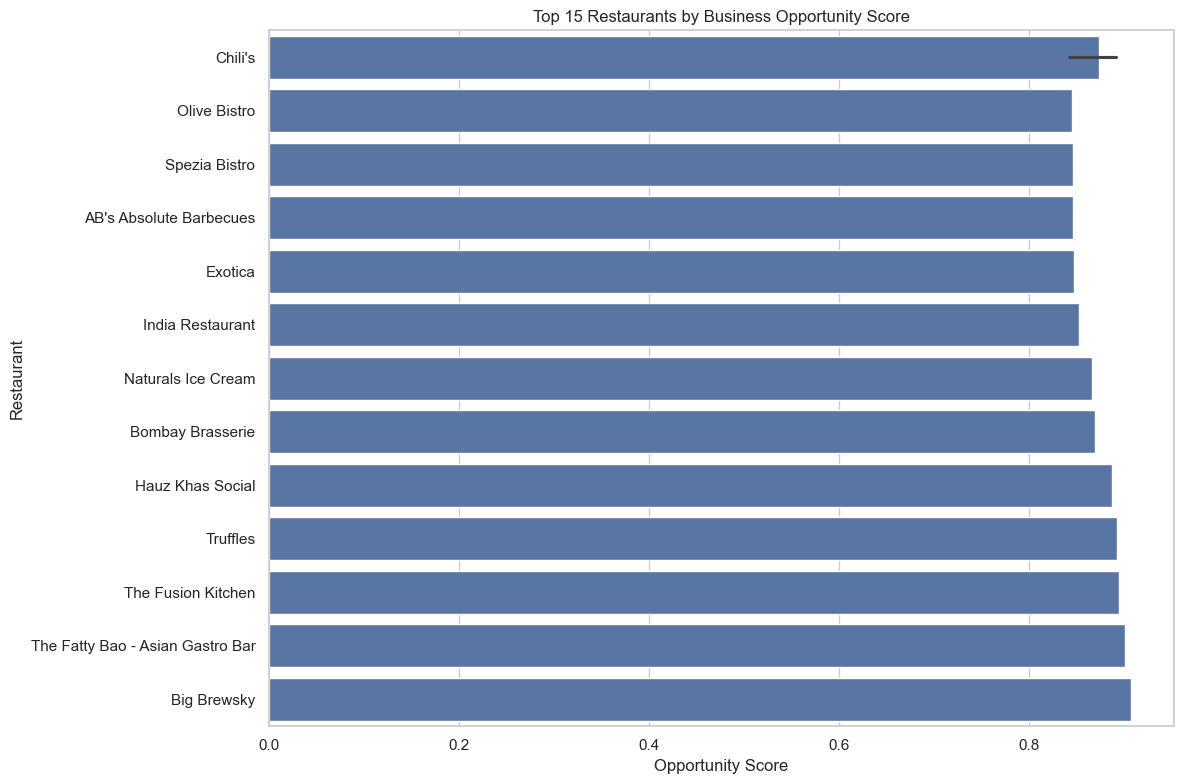

In [14]:
plt.figure(figsize=(12, 8))

plot_data = top_opportunities.head(15).sort_values(
    "Opportunity Score"
)

sns.barplot(
    data=plot_data,
    x="Opportunity Score",
    y="Restaurant Name"
)

plt.title("Top 15 Restaurants by Business Opportunity Score")
plt.xlabel("Opportunity Score")
plt.ylabel("Restaurant")

plt.tight_layout()
plt.show()

In [15]:

validation = (
    df[
        [
            "Restaurant Name",
            "City",
            "Aggregate rating",
            "Votes",
            "Average Cost for two",
            "Performance Score",
            "Value Score",
            "Digital Adoption",
            "Opportunity Score"
        ]
    ]
    .sort_values("Opportunity Score", ascending=False)
    .head(15)
)

display(validation)

,Restaurant Name,City,Aggregate rating,Votes,Average Cost for two,Performance Score,Value Score,Digital Adoption,Opportunity Score
735,Big Brewsky,Bangalore,4.5,5705,1800.0,0.888748,0.909005,Both Services,0.906903
719,The Fatty Bao - Asian Gastro Bar,Bangalore,4.7,2369,2400.0,0.881757,0.953941,Both Services,0.900470
2145,The Fusion Kitchen,Mumbai,4.7,2083,1000.0,0.875068,0.954466,Both Services,0.894643
727,Truffles,Bangalore,4.7,9667,800.0,0.954885,0.954541,One Service,0.891897
1964,Chili's,Hyderabad,4.7,1932,1800.0,0.871156,0.954166,Both Services,0.890974
801,Chili's,Chennai,4.8,1262,1700.0,0.868375,0.976784,Both Services,0.888468
3374,Hauz Khas Social,New Delhi,4.3,7931,1600.0,0.867171,0.863919,Both Services,0.887421
806,Bombay Brasserie,Chennai,4.6,1753,1200.0,0.846747,0.931811,Both Services,0.868989
2593,Naturals Ice Cream,New Delhi,4.9,2620,150.0,0.925703,0.999946,One Service,0.865586
2069,India Restaurant,Kolkata,4.6,1219,800.0,0.827863,0.931961,Both Services,0.851966


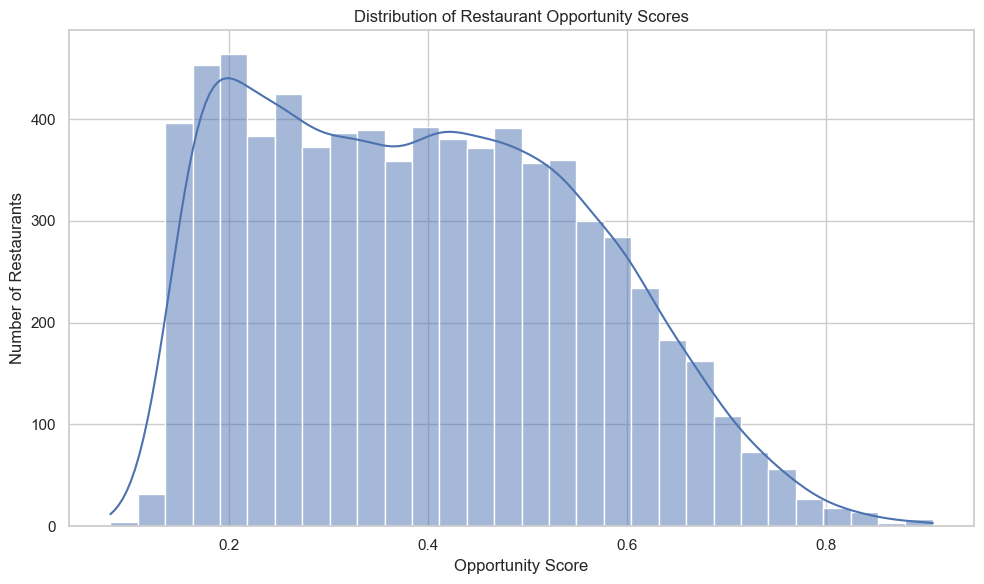

In [16]:
plt.figure(figsize=(10, 6))

sns.histplot(
    data=df,
    x="Opportunity Score",
    bins=30,
    kde=True
)

plt.title("Distribution of Restaurant Opportunity Scores")
plt.xlabel("Opportunity Score")
plt.ylabel("Number of Restaurants")

plt.tight_layout()
plt.show()

In [17]:

city_opportunity = (
    df
    .groupby("City")
    .agg(
        Restaurant_Count=("Restaurant Name", "count"),
        Average_Rating=("Aggregate rating", "mean"),
        Average_Performance=("Performance Score", "mean"),
        Average_Value=("Value Score", "mean"),
        Average_Opportunity=("Opportunity Score", "mean"),
        Total_Votes=("Votes", "sum")
    )
    .reset_index()
)

# Keep cities with at least 30 restaurants
city_opportunity_filtered = (
    city_opportunity[
        city_opportunity["Restaurant_Count"] >= 30
    ]
    .sort_values(
        "Average_Opportunity",
        ascending=False
    )
)

display(
    city_opportunity_filtered.head(20)
)

,City,Restaurant_Count,Average_Rating,Average_Performance,Average_Value,Average_Opportunity,Total_Votes
50,Gurgaon,890,3.330674,0.417182,0.645339,0.382084,131978
88,New Delhi,4048,3.297381,0.407858,0.637861,0.361324,627090
89,Noida,696,3.159626,0.372000,0.606779,0.336670,73148
43,Faridabad,151,3.103311,0.328665,0.594114,0.272247,6406


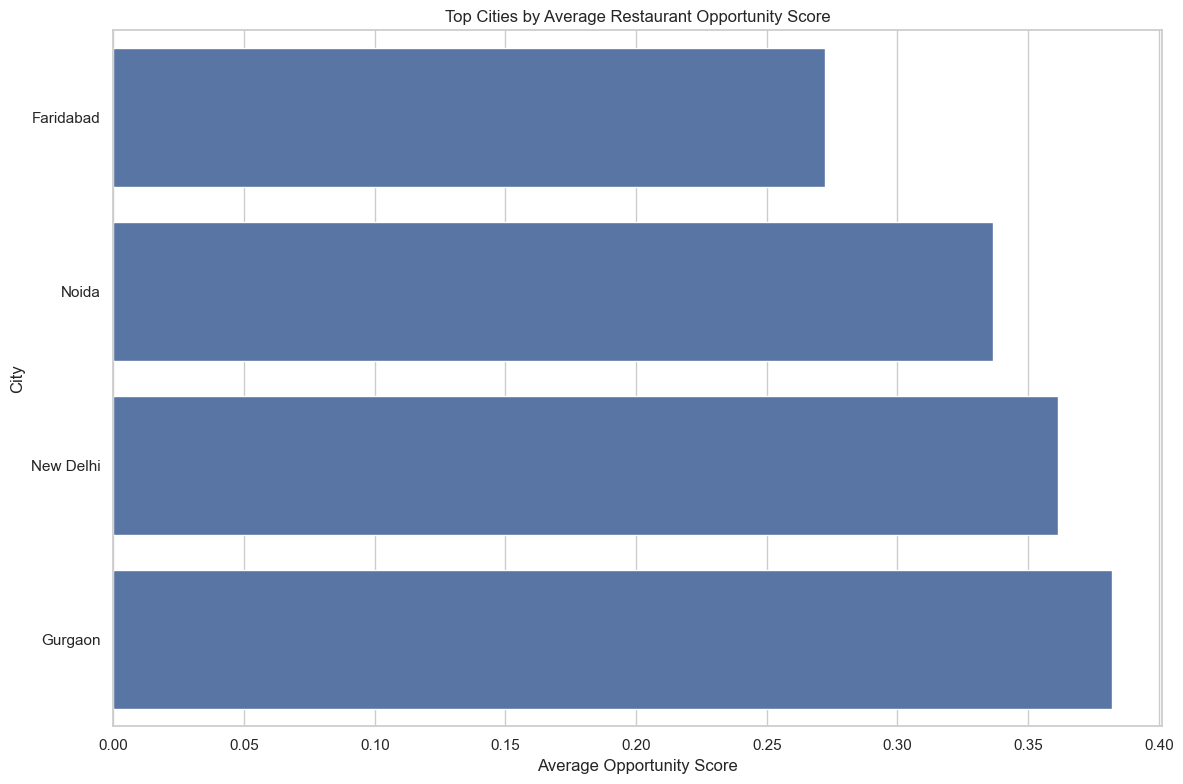

In [18]:
plt.figure(figsize=(12, 8))

plot_city = (
    city_opportunity_filtered
    .head(15)
    .sort_values("Average_Opportunity")
)

sns.barplot(
    data=plot_city,
    x="Average_Opportunity",
    y="City"
)

plt.title("Top Cities by Average Restaurant Opportunity Score")
plt.xlabel("Average Opportunity Score")
plt.ylabel("City")

plt.tight_layout()
plt.show()

In [19]:

cuisine_df = df[
    ["Restaurant Name", "Cuisines", "Aggregate rating",
     "Votes", "Performance Score", "Value Score",
     "Opportunity Score"]
].dropna(subset=["Cuisines"]).copy()

cuisine_df["Cuisines"] = (
    cuisine_df["Cuisines"]
    .str.split(", ")
)

cuisine_df = cuisine_df.explode("Cuisines")

cuisine_opportunity = (
    cuisine_df
    .groupby("Cuisines")
    .agg(
        Restaurant_Count=("Restaurant Name", "count"),
        Average_Rating=("Aggregate rating", "mean"),
        Average_Performance=("Performance Score", "mean"),
        Average_Value=("Value Score", "mean"),
        Average_Opportunity=("Opportunity Score", "mean"),
        Total_Votes=("Votes", "sum")
    )
    .reset_index()
)

# Minimum 20 restaurants
cuisine_opportunity_filtered = (
    cuisine_opportunity[
        cuisine_opportunity["Restaurant_Count"] >= 20
    ]
    .sort_values(
        "Average_Opportunity",
        ascending=False
    )
)

display(
    cuisine_opportunity_filtered.head(20)
)

,Cuisines,Restaurant_Count,Average_Rating,Average_Performance,Average_Value,Average_Opportunity,Total_Votes
86,Mediterranean,110,4.020000,0.645292,0.800797,0.590576,80532
64,Indian,66,4.156061,0.645833,0.833838,0.580476,22391
47,European,146,3.964384,0.632821,0.788106,0.579312,103305
55,Goan,20,3.970000,0.642776,0.789597,0.575727,11488
88,Middle Eastern,21,3.942857,0.613562,0.783392,0.572298,7674
122,Southern,24,4.129167,0.676288,0.825933,0.564961,13939
66,International,21,4.247619,0.660102,0.852615,0.553854,8122
140,Vegetarian,23,4.073913,0.660133,0.813457,0.550347,10714
7,Asian,228,3.898684,0.595717,0.771701,0.547382,104298
116,Seafood,171,3.929825,0.614636,0.780182,0.540887,74254


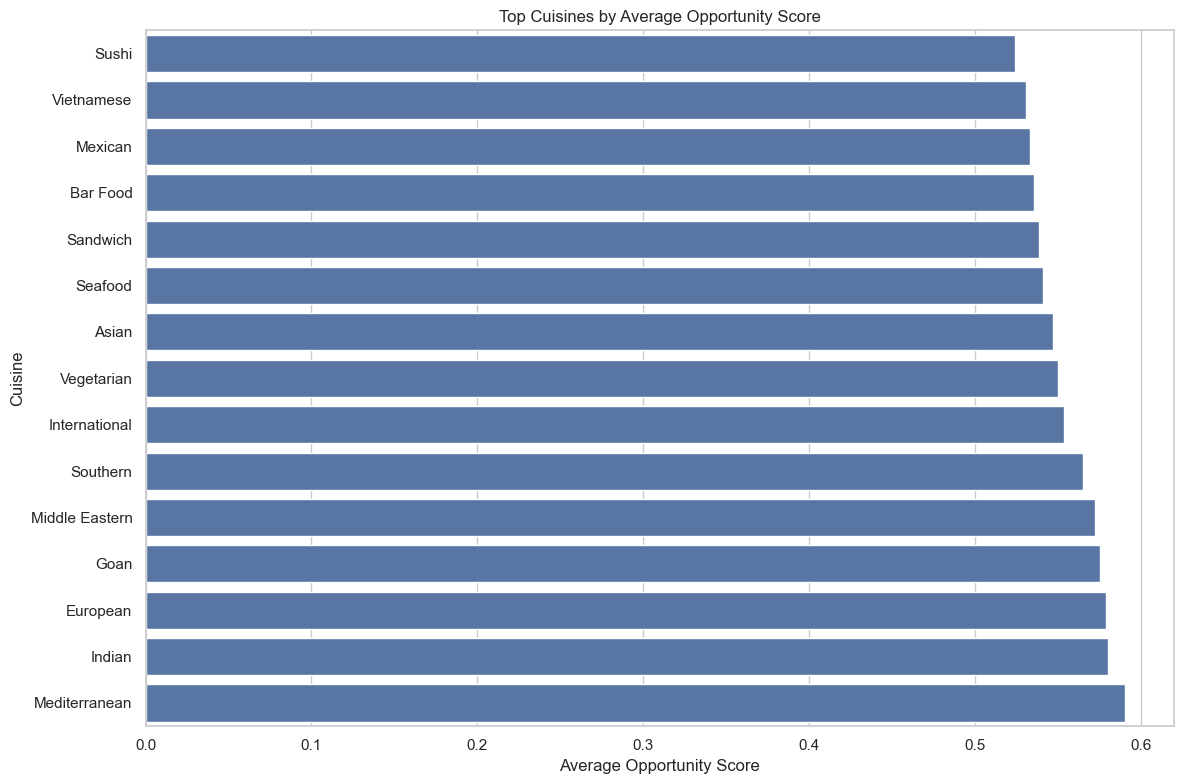

In [20]:
plt.figure(figsize=(12, 8))

plot_cuisine = (
    cuisine_opportunity_filtered
    .head(15)
    .sort_values("Average_Opportunity")
)

sns.barplot(
    data=plot_cuisine,
    x="Average_Opportunity",
    y="Cuisines"
)

plt.title("Top Cuisines by Average Opportunity Score")
plt.xlabel("Average Opportunity Score")
plt.ylabel("Cuisine")

plt.tight_layout()
plt.show()


In [ ]:
best_restaurant = (
    df.sort_values("Opportunity Score", ascending=False)
      .iloc[0]
)

best_city = (
    city_opportunity_filtered
    .sort_values("Average_Opportunity", ascending=False)
    .iloc[0]
)

best_cuisine = (
    cuisine_opportunity_filtered
    .sort_values("Average_Opportunity", ascending=False)
    .iloc[0]
)

largest_segment = (
    df["Performance Segment"]
    .value_counts()
    .idxmax()
)

best_digital = (
    df.groupby("Digital Adoption")["Opportunity Score"]
      .mean()
      .sort_values(ascending=False)
      .index[0]
)

print("=" * 70)
print("RESTAURANT ANALYTICS — EXECUTIVE INSIGHTS")
print("=" * 70)

print(
    f"\n🏆 Top Restaurant Opportunity:"
    f"\n   {best_restaurant['Restaurant Name']}"
    f" — {best_restaurant['City']}"
)

print(
    f"\n📍 Top City Opportunity:"
    f"\n   {best_city['City']}"
)

print(
    f"\n🍜 Top Cuisine Opportunity:"
    f"\n   {best_cuisine['Cuisines']}"
)

print(
    f"\n📊 Largest Performance Segment:"
    f"\n   {largest_segment}"
)

print(
    f"\n📱 Strongest Digital Adoption Group:"
    f"\n   {best_digital}"
)

RESTAURANT ANALYTICS — EXECUTIVE INSIGHTS

🏆 Top Restaurant Opportunity:
   Big Brewsky — Bangalore

📍 Top City Opportunity:
   Gurgaon

🍜 Top Cuisine Opportunity:
   Mediterranean

📊 Largest Performance Segment:
   High Performer

📱 Strongest Digital Adoption Group:
   Both Services


In [22]:
executive_summary = pd.DataFrame({
    "Insight": [
        "Top Restaurant Opportunity",
        "Top City Opportunity",
        "Top Cuisine Opportunity",
        "Largest Performance Segment",
        "Strongest Digital Adoption Group"
    ],
    
    "Result": [
        f"{best_restaurant['Restaurant Name']} ({best_restaurant['City']})",
        best_city["City"],
        best_cuisine["Cuisines"],
        largest_segment,
        best_digital
    ]
})

display(executive_summary)

,Insight,Result
0,Top Restaurant Opportunity,Big Brewsky (Bangalore)
1,Top City Opportunity,Gurgaon
2,Top Cuisine Opportunity,Mediterranean
3,Largest Performance Segment,High Performer
4,Strongest Digital Adoption Group,Both Services


In [23]:
executive_summary.to_csv(
    "../data/executive_business_insights.csv",
    index=False
)

print("Executive insights saved successfully.")

Executive insights saved successfully.


In [24]:
df.to_csv(
    "../data/restaurant_business_intelligence.csv",
    index=False
)

print("Final Business Intelligence dataset saved!")
print("Shape:", df.shape)

Final Business Intelligence dataset saved!
Shape: (7403, 33)
